# 📊 Análise Exploratória de Dados - Predição de Limite de Crédito

## 🎯 Objetivos
- Entender a distribuição das variáveis
- Identificar valores faltantes e inconsistências
- Analisar correlações
- Explorar padrões relacionados ao limite de crédito

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [4]:
df = pd.read_csv("../data/raw/Credit.csv")

df.head()

,Unnamed: 0,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
0,1,14.891,3606,283,2,34,11,Male,No,Yes,Caucasian,333
1,2,106.025,6645,483,3,82,15,Female,Yes,Yes,Asian,903
2,3,104.593,7075,514,4,71,11,Male,No,No,Asian,580
3,4,148.924,9504,681,3,36,11,Female,No,No,Asian,964
4,5,55.882,4897,357,2,68,16,Male,No,Yes,Caucasian,331


In [5]:
df.shape

(400, 12)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  400 non-null    int64  
 1   Income      400 non-null    float64
 2   Limit       400 non-null    int64  
 3   Rating      400 non-null    int64  
 4   Cards       400 non-null    int64  
 5   Age         400 non-null    int64  
 6   Education   400 non-null    int64  
 7   Gender      400 non-null    str    
 8   Student     400 non-null    str    
 9   Married     400 non-null    str    
 10  Ethnicity   400 non-null    str    
 11  Balance     400 non-null    int64  
dtypes: float64(1), int64(7), str(4)
memory usage: 37.6 KB


In [7]:
df.describe()

,Unnamed: 0,Income,Limit,Rating,Cards,Age,Education,Balance
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,200.500000,45.218885,4735.600000,354.940000,2.957500,55.667500,13.450000,520.015000
std,115.614301,35.244273,2308.198848,154.724143,1.371275,17.249807,3.125207,459.758877
min,1.000000,10.354000,855.000000,93.000000,1.000000,23.000000,5.000000,0.000000
25%,100.750000,21.007250,3088.000000,247.250000,2.000000,41.750000,11.000000,68.750000
50%,200.500000,33.115500,4622.500000,344.000000,3.000000,56.000000,14.000000,459.500000
75%,300.250000,57.470750,5872.750000,437.250000,4.000000,70.000000,16.000000,863.000000
max,400.000000,186.634000,13913.000000,982.000000,9.000000,98.000000,20.000000,1999.000000


In [8]:
df.isnull().sum()

Unnamed: 0    0
Income        0
Limit         0
Rating        0
Cards         0
Age           0
Education     0
Gender        0
Student       0
Married       0
Ethnicity     0
Balance       0
dtype: int64

In [10]:
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Variáveis categóricas:", list(categorical_cols))
print("Variáveis numéricas:", list(numerical_cols))

Variáveis categóricas: ['Gender', 'Student', 'Married', 'Ethnicity']
Variáveis numéricas: ['Unnamed: 0', 'Income', 'Limit', 'Rating', 'Cards', 'Age', 'Education', 'Balance']


C:\Users\guilh\AppData\Local\Temp\ipykernel_15592\3626606042.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


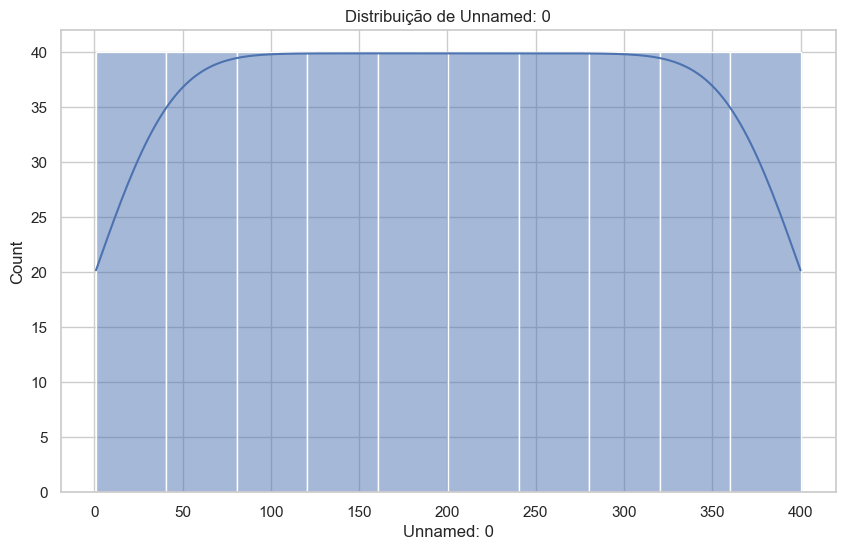

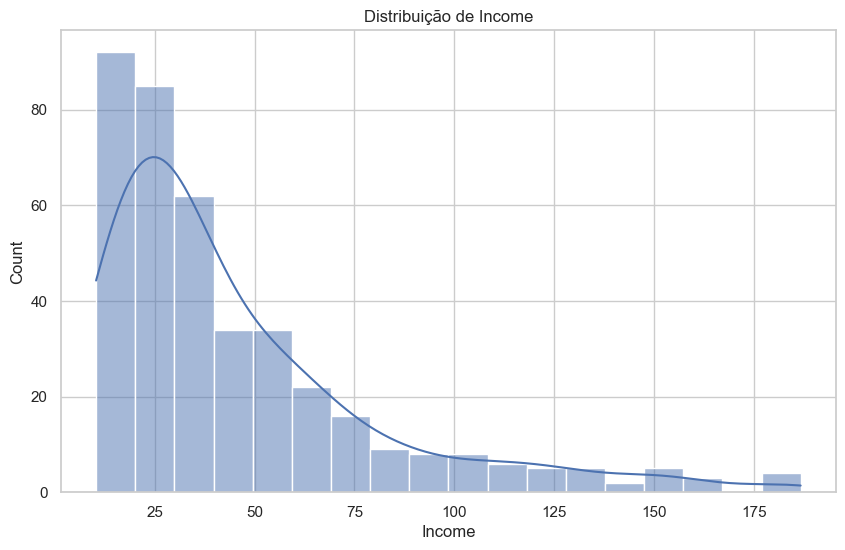

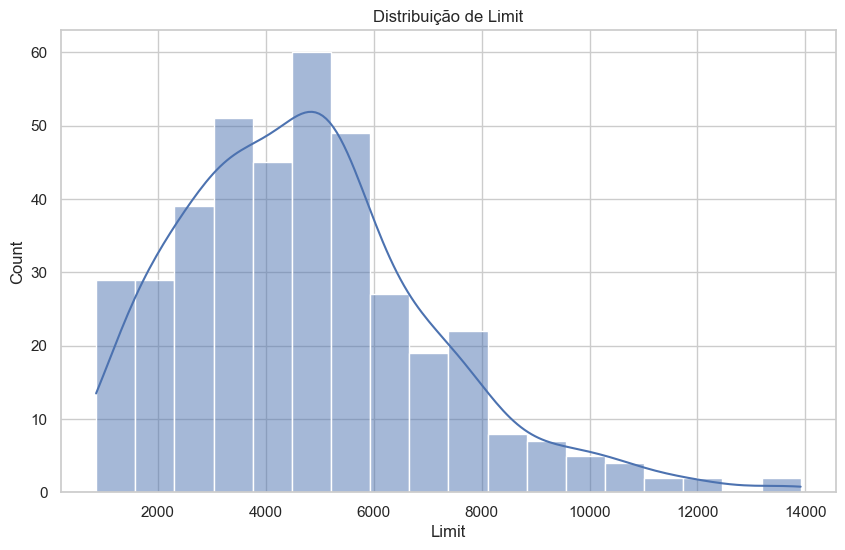

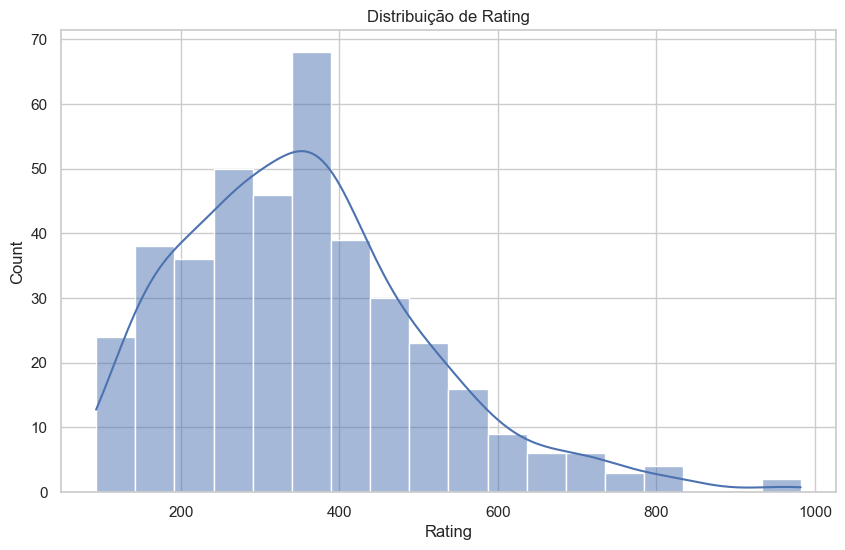

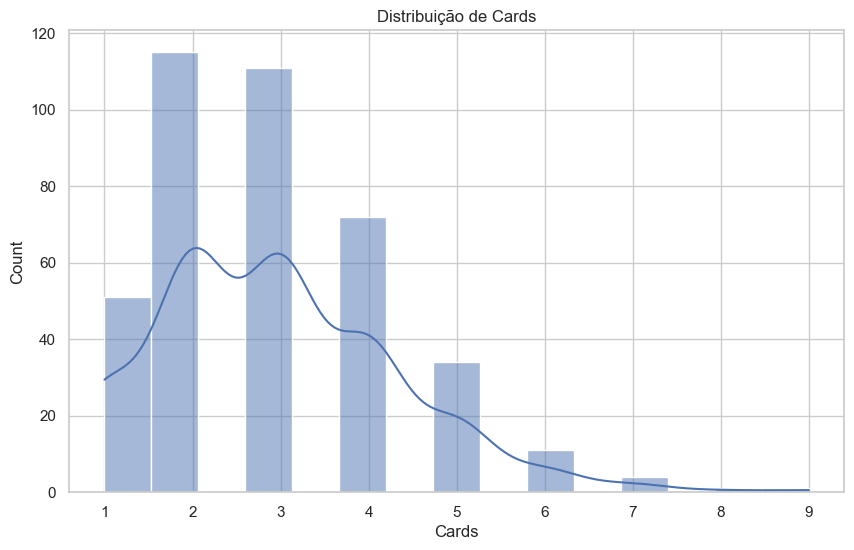

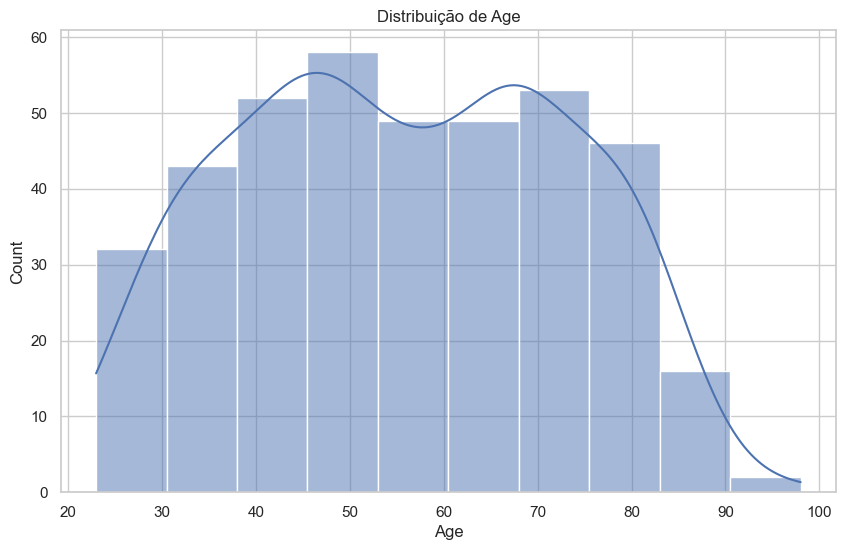

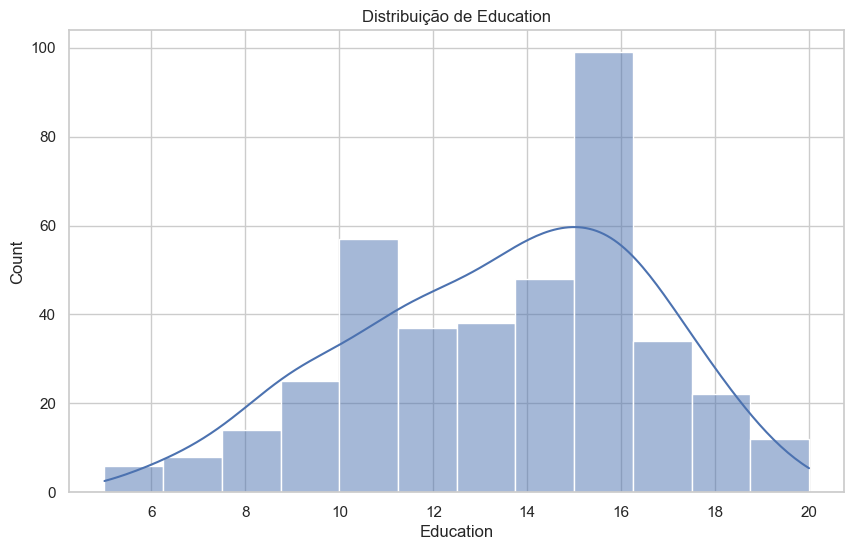

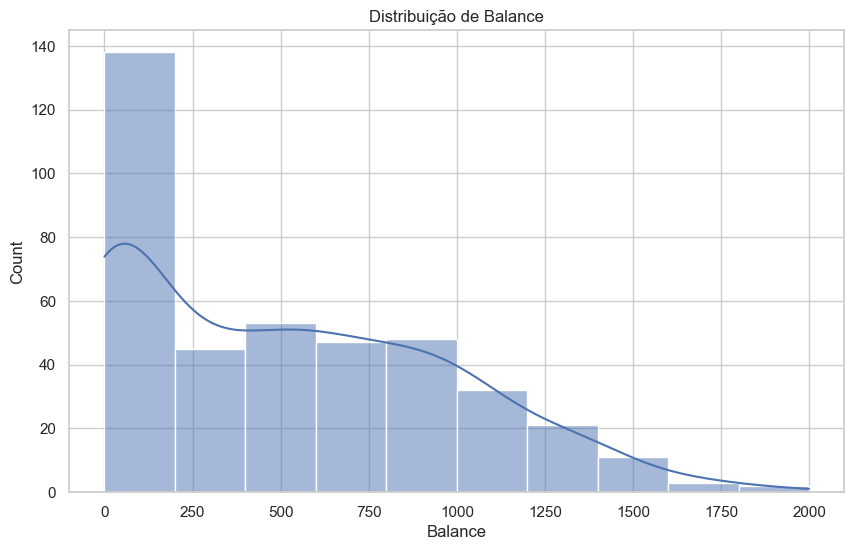

In [11]:
for col in numerical_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribuição de {col}")
    plt.show()

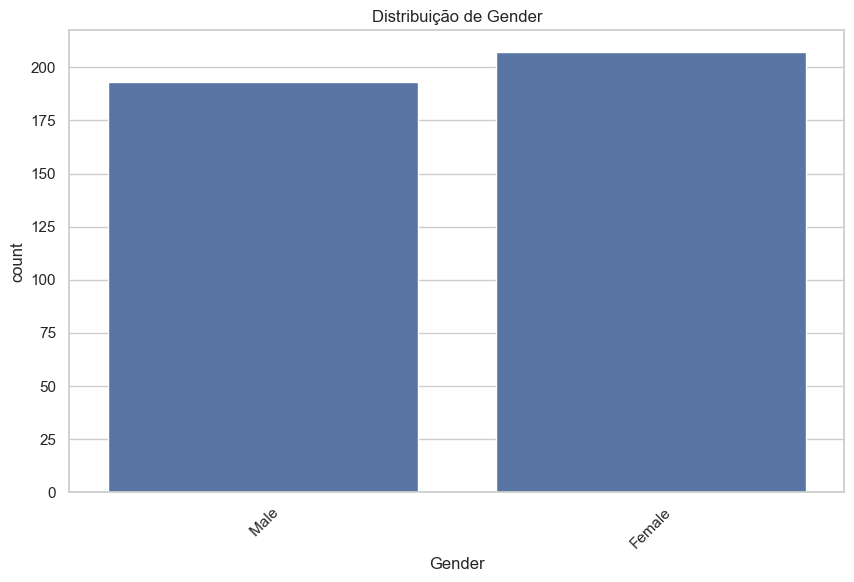

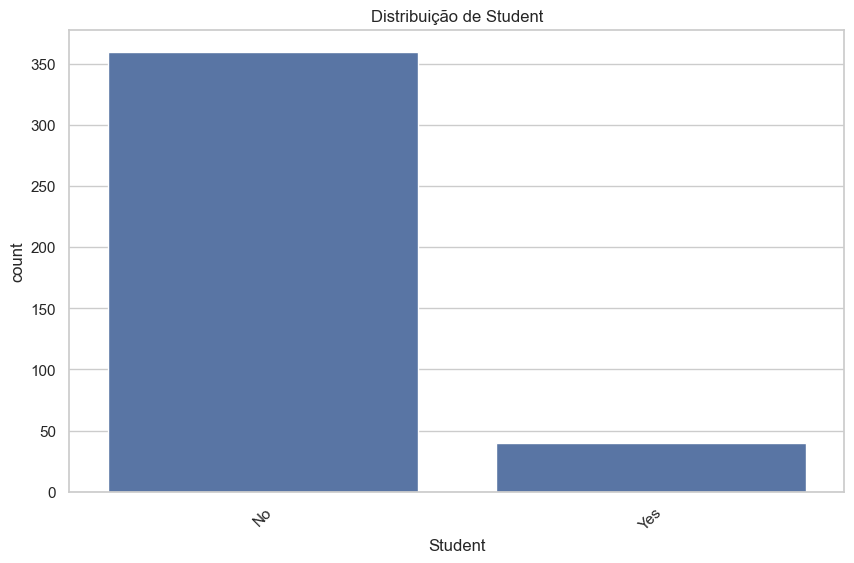

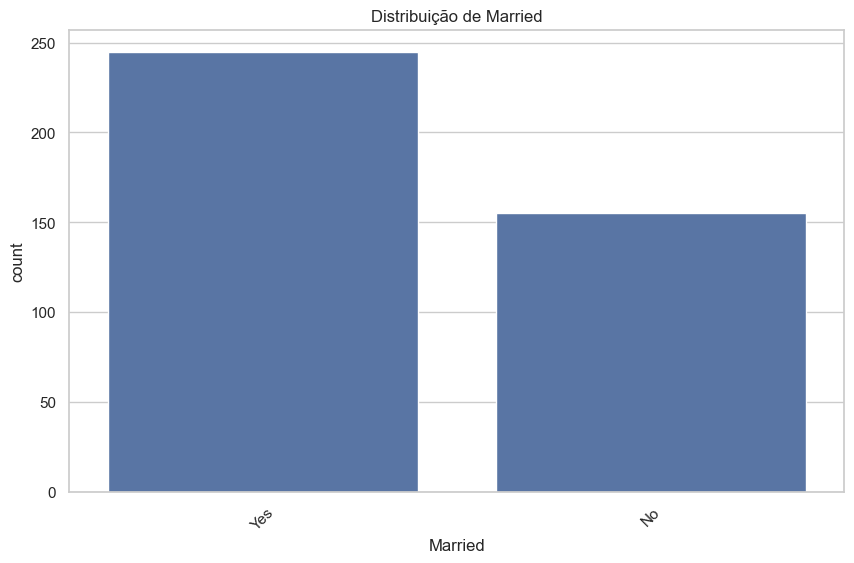

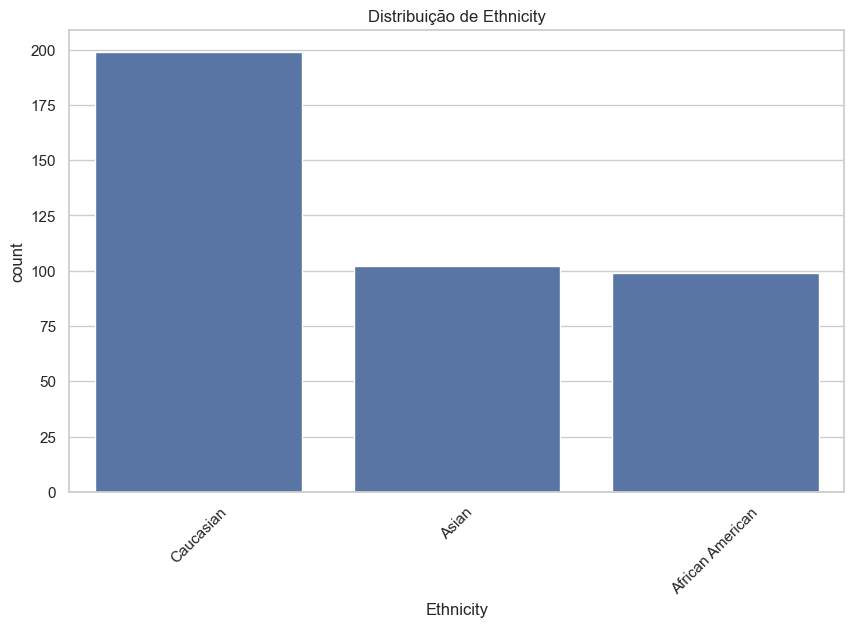

In [12]:
for col in categorical_cols:
    plt.figure()
    sns.countplot(x=col, data=df)
    plt.title(f"Distribuição de {col}")
    plt.xticks(rotation=45)
    plt.show()

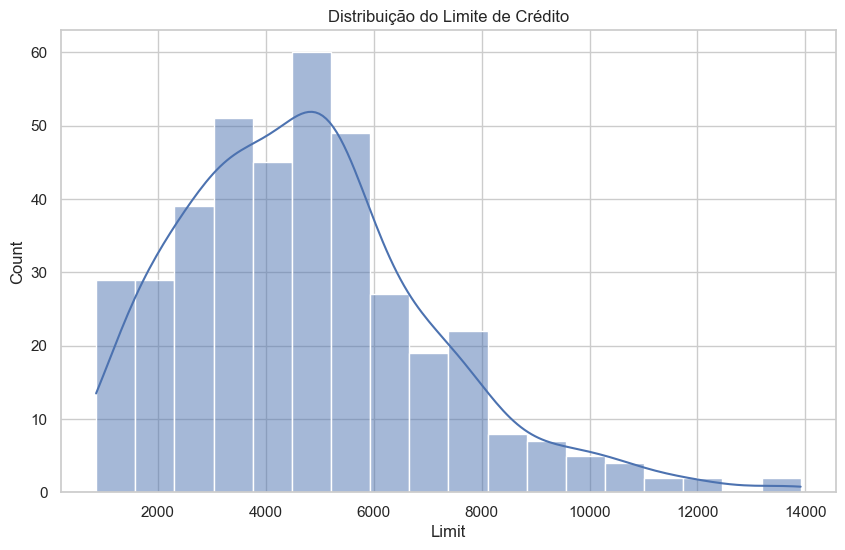

In [13]:
sns.histplot(df['Limit'], kde=True)
plt.title("Distribuição do Limite de Crédito")
plt.show()

In [14]:
df['Limit'].describe()

count      400.000000
mean      4735.600000
std       2308.198848
min        855.000000
25%       3088.000000
50%       4622.500000
75%       5872.750000
max      13913.000000
Name: Limit, dtype: float64

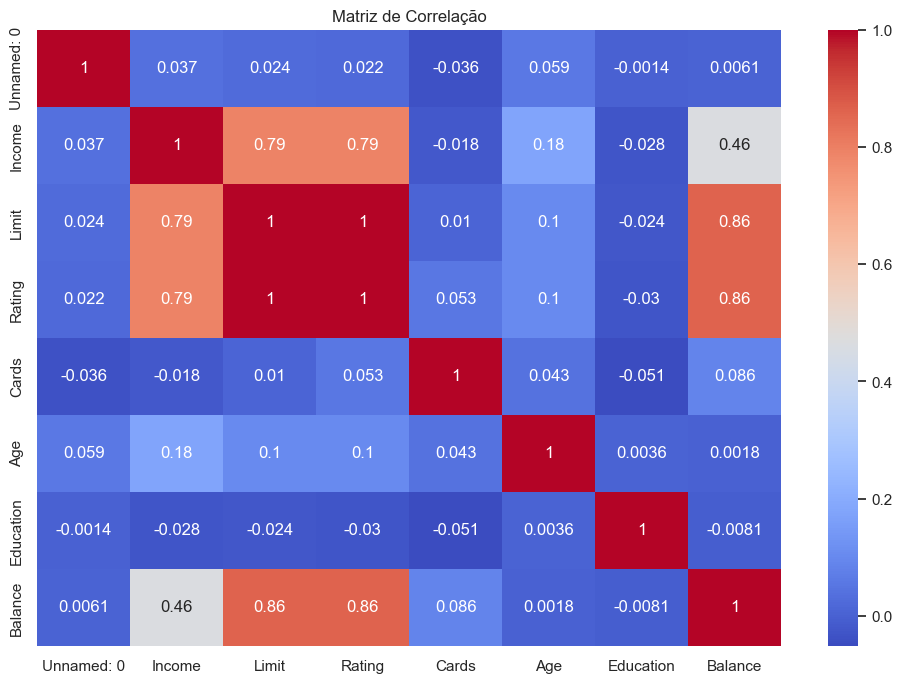

In [15]:
corr = df[numerical_cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()

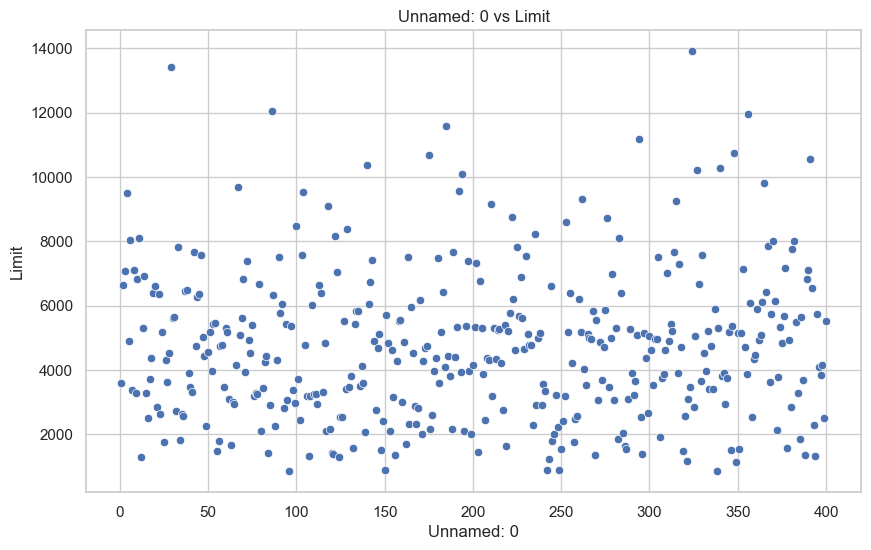

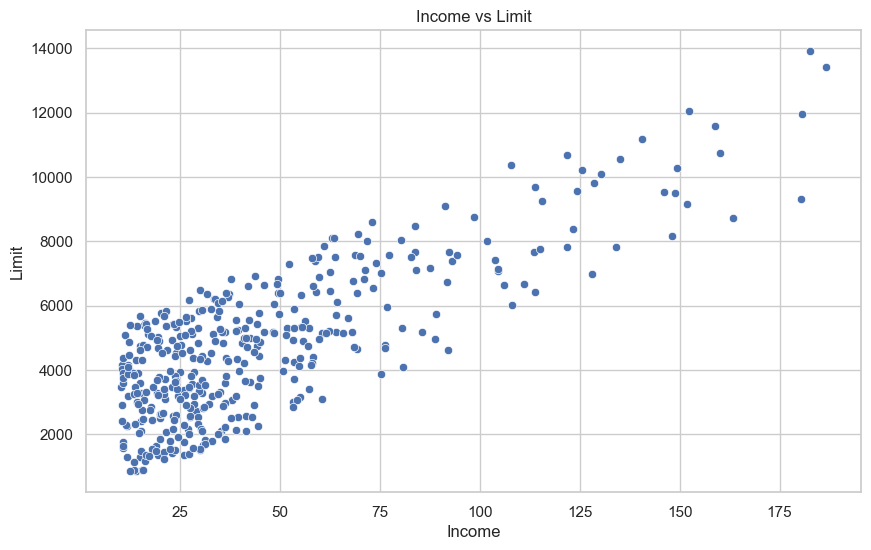

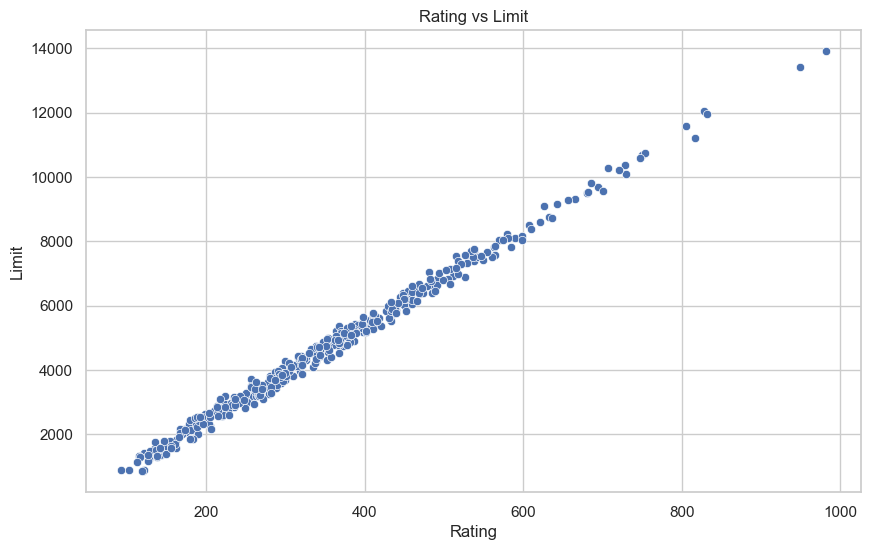

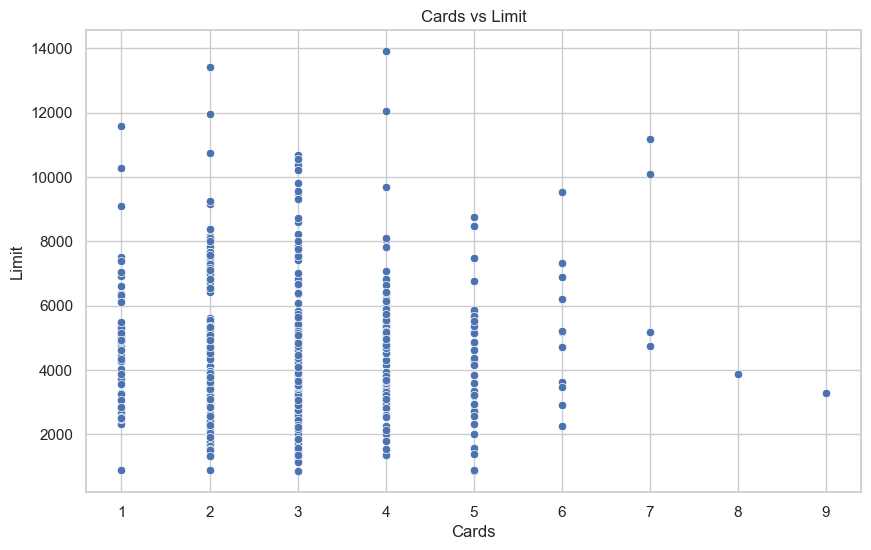

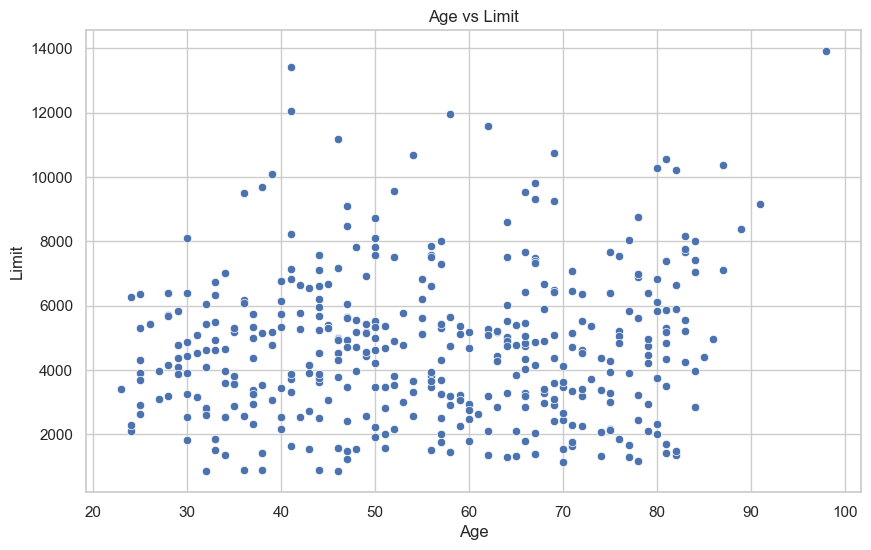

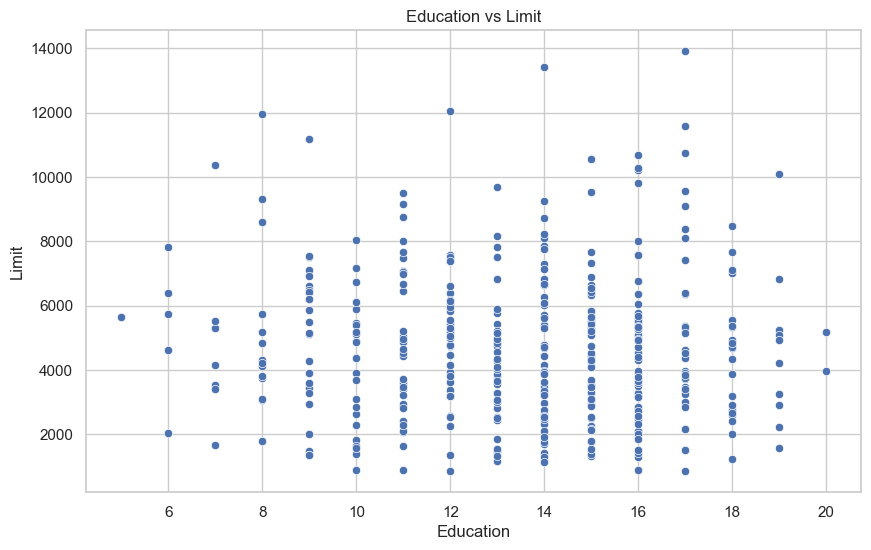

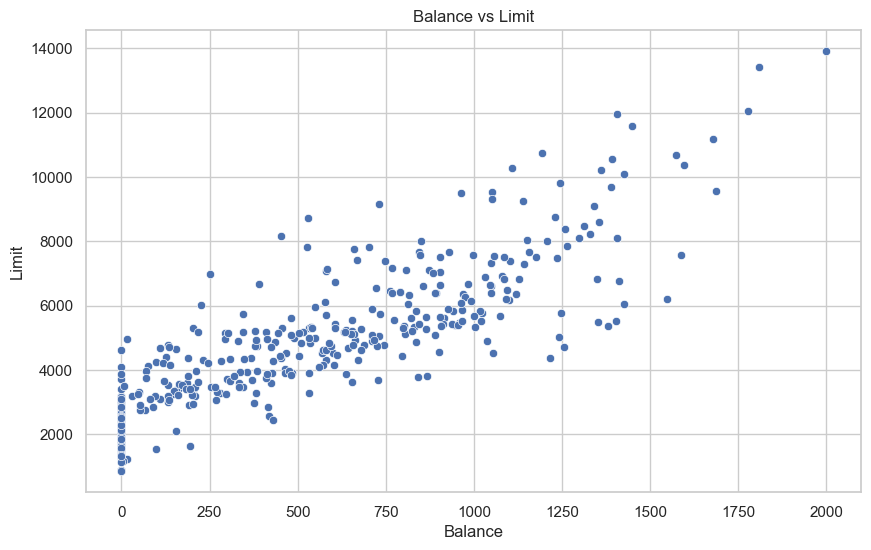

In [16]:
for col in numerical_cols:
    if col != 'Limit':
        plt.figure()
        sns.scatterplot(x=df[col], y=df['Limit'])
        plt.title(f"{col} vs Limit")
        plt.show()

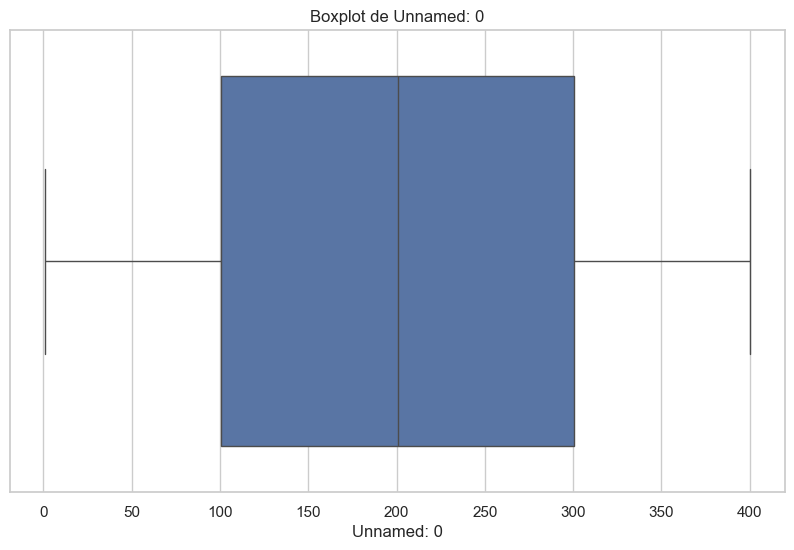

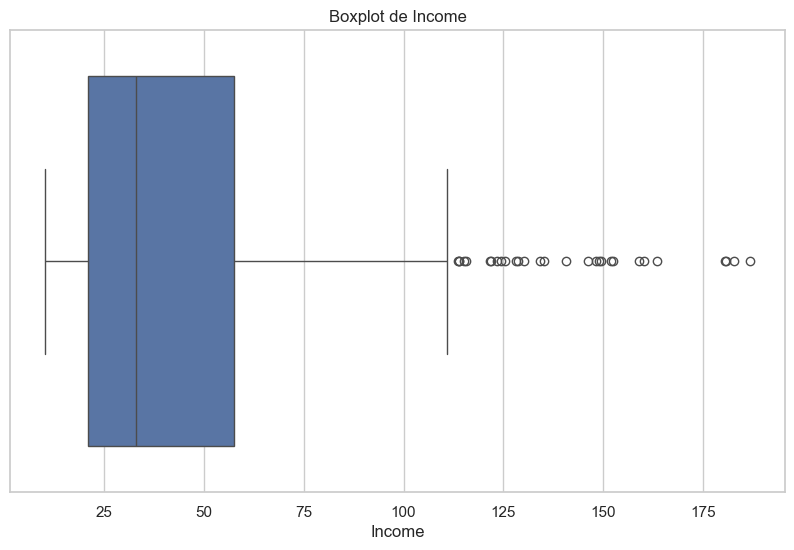

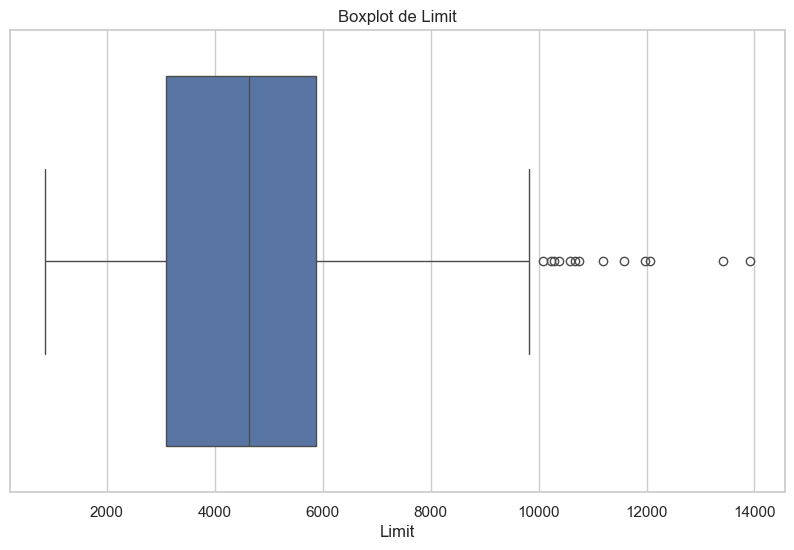

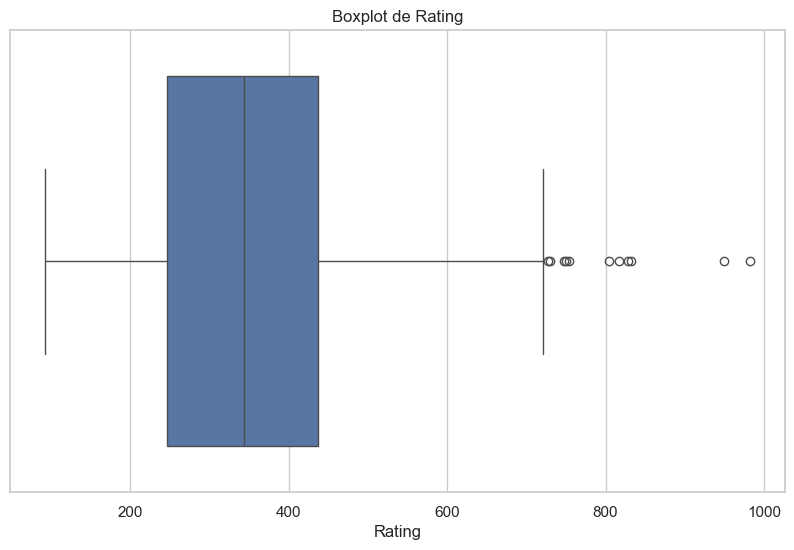

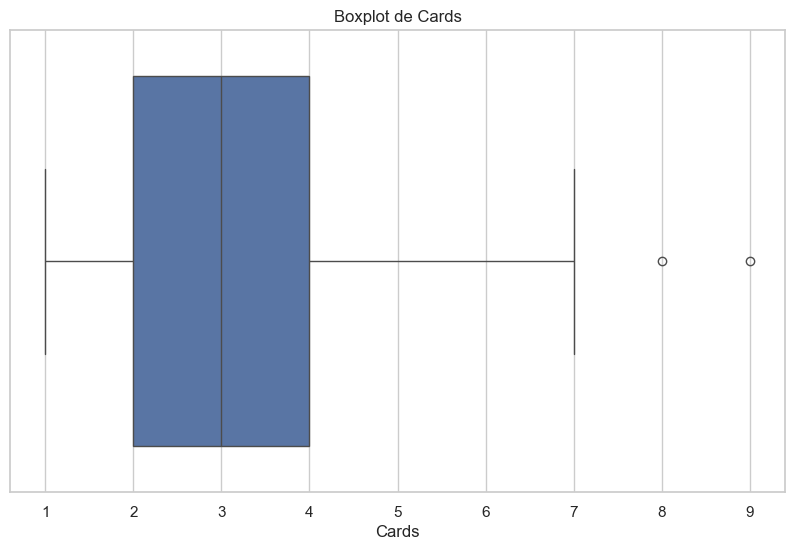

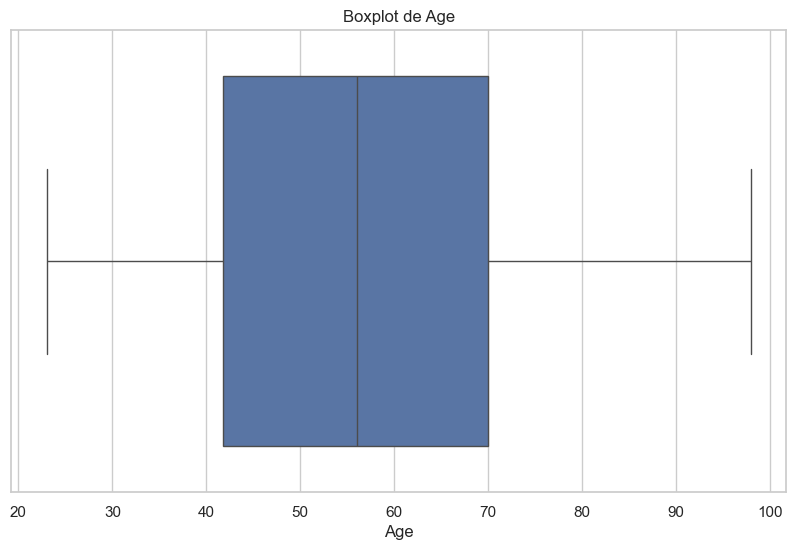

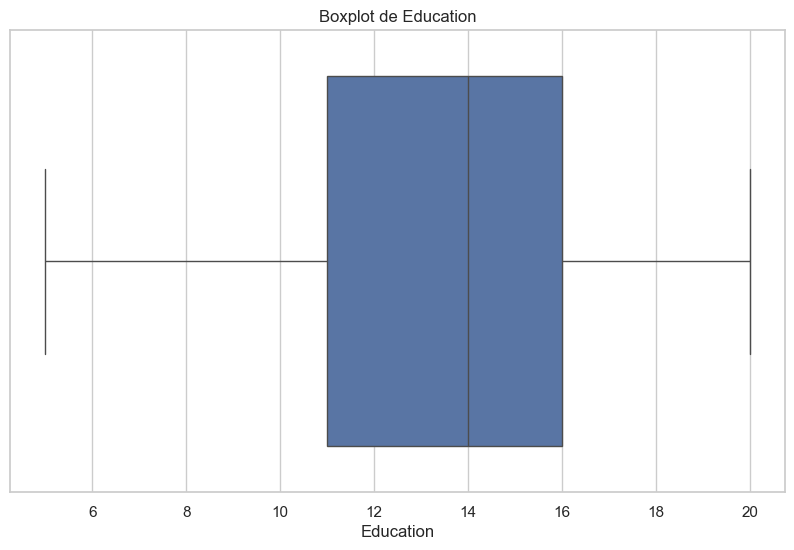

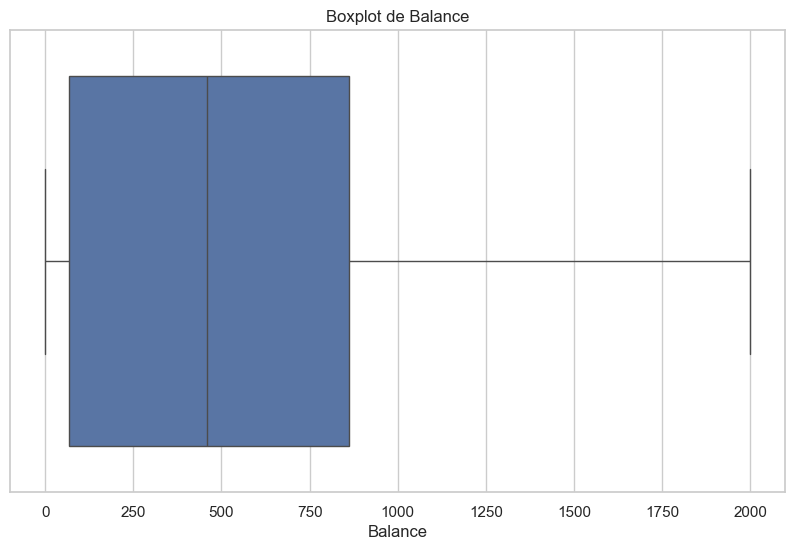

In [17]:
for col in numerical_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

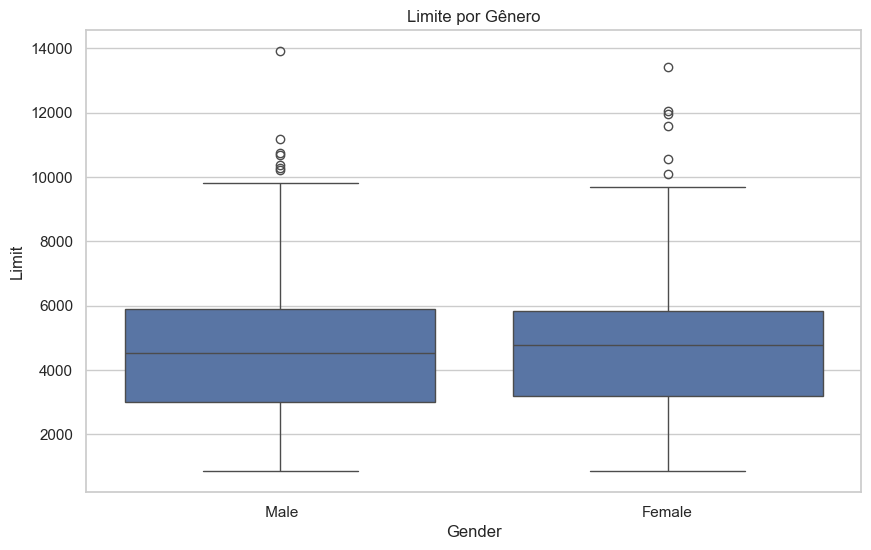

In [18]:
sns.boxplot(x='Gender', y='Limit', data=df)
plt.title("Limite por Gênero")
plt.show()

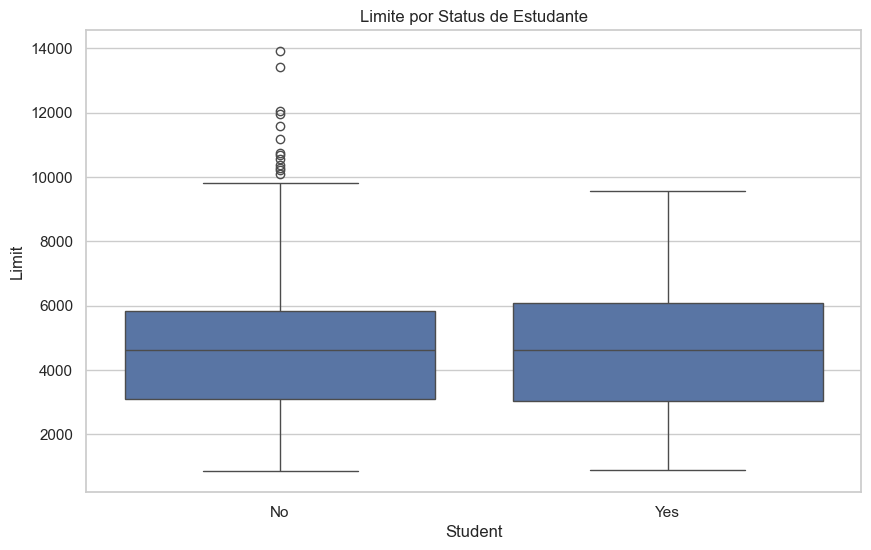

In [19]:
sns.boxplot(x='Student', y='Limit', data=df)
plt.title("Limite por Status de Estudante")
plt.show()